In [35]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [36]:
# load dataset 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, sep=';')

In [37]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [38]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [39]:
# Features and target 
X = data.drop("quality", axis=1)
y = data['quality']

In [56]:
print(X)

      fixed acidity  volatile acidity  citric acid  residual sugar  ...  density    pH  sulphates  alcohol
0               7.4             0.700         0.00             1.9  ...  0.99780  3.51       0.56      9.4
1               7.8             0.880         0.00             2.6  ...  0.99680  3.20       0.68      9.8
2               7.8             0.760         0.04             2.3  ...  0.99700  3.26       0.65      9.8
3              11.2             0.280         0.56             1.9  ...  0.99800  3.16       0.58      9.8
4               7.4             0.700         0.00             1.9  ...  0.99780  3.51       0.56      9.4
...             ...               ...          ...             ...  ...      ...   ...        ...      ...
1594            6.2             0.600         0.08             2.0  ...  0.99490  3.45       0.58     10.5
1595            5.9             0.550         0.10             2.2  ...  0.99512  3.52       0.76     11.2
1596            6.3             0.510

In [57]:
print(y)

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64


In [58]:
# For simplicity, convert quality scores to binary classification:
# quality >= 6 as 'good' (1), else 'bad' (0)
y_binary = (y >= 6).astype(int)

In [59]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)

In [43]:
X_train.shape, y_train.shape

((1119, 11), (1119,))

In [44]:
# Scaling Feature 
minmaxScaler = MinMaxScaler()
standardScaler = StandardScaler()

In [45]:
X_train_scaledMinMax = minmaxScaler.fit_transform(X_train)
X_train_scaledStandard = standardScaler.fit_transform(X_train)

In [46]:
# Transform test data using the already fitted scaler 
X_test_scaledMinMax = minmaxScaler.transform(X_test)
X_test_scaledStandard = standardScaler.transform(X_test)

In [47]:
# Train and evaluate
knn_MinMax = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaledMinMax, y_train)
knn_Standard = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaledStandard, y_train)

In [48]:
print("Accuracy on test set:", knn_MinMax.score(X_test_scaledMinMax, y_test))
print("Accuracy on test set:", knn_Standard.score(X_test_scaledStandard, y_test))

Accuracy on test set: 0.6854166666666667
Accuracy on test set: 0.725


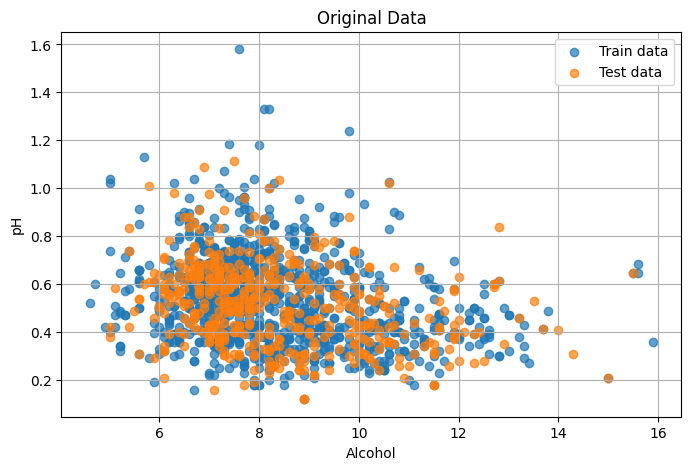

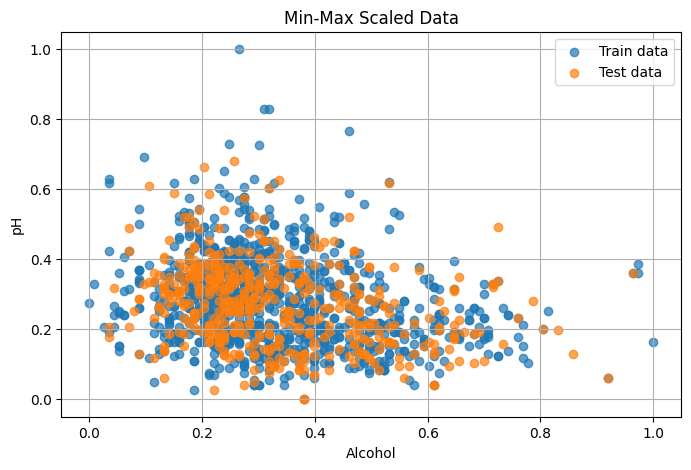

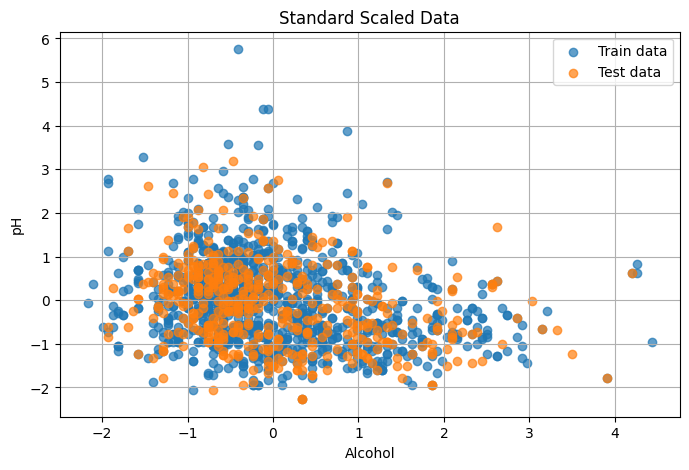

In [54]:
import matplotlib.pyplot as plt
# Plot function to make it easy
def plot_data(X1, X2, title):
    plt.figure(figsize=(8,5))
    plt.scatter(X1[:, 0], X1[:, 1], label='Train data', alpha=0.7)
    plt.scatter(X2[:, 0], X2[:, 1], label='Test data', alpha=0.7)
    plt.xlabel('Alcohol')
    plt.ylabel('pH')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot Original Data (only train and test, no scaling)
plot_data(X_train.values, X_test.values, 'Original Data')

# Plot Min-Max Scaled Data
plot_data(X_train_scaledMinMax, X_test_scaledMinMax, 'Min-Max Scaled Data')

# Plot Standard Scaled Data
plot_data(X_train_scaledStandard, X_test_scaledStandard, 'Standard Scaled Data')